In [63]:
import json

#file_path = "./benchmark_results/second bench/corrected-gemini-2.5-flash-preview-05-20.json"
#file_path = "./benchmark_results/second bench/corrected-gemini-2.5-pro-preview-06-05-low.json"
#file_path = "./benchmark_results/second bench/corrected-gemini-2.5-pro-preview-06-05-medium.json"
#file_path = "./benchmark_results/second bench/gemini-2.5-pro-preview-06-05-high.json"

#file_path = "./benchmark_results/second bench/gemini-2.5-flash-preview-05-20 avec prompt v2.json"
#file_path = "./benchmark_results/second bench/gemini-2.5-flash-preview-05-20 avec prompt v3.json"
#file_path = "./benchmark_results/second bench/gemini-2.5-flash-preview-05-20 avec prompt v3 + correc.json"
file_path = "./benchmark_results/second bench/gemini-2.5-flash-preview-05-20 avec prompt v3.6.json"


with open(file_path, 'r', encoding='utf-8') as f:
	results_pre = json.load(f)

In [14]:
categ = "alLin"
student = "9"
exercise = "1"

ex = results_pre[categ][student][exercise]

In [12]:
print("==========================================")
print(ex["errors"])
print("==========================================")
print(ex["response"])
print("==========================================")

{'1': {'line': 71, 'description': 'erreur de calcul, (\\Gamma = (x-2)^2+(y-0)^2 = \\sqrt{10}) devrait être égal à (\\Gamma = (x-2)^2+(y-0)^2 = (\\sqrt{10})^2)'}, '2': {'line': 86, 'description': 'mauvaise réponse'}}
```json
{
"line":"e \\Rightarrow y = x-2",
"number":"35",
"desc":"The equation for line 'e' is incorrect. Line 'e' is orthogonal to line 'd'. The direction vector of 'd' is (3,1), meaning its slope is 1/3. For 'e' to be orthogonal to 'd', its slope must be -3. The student's equation y = x-2 has a slope of 1, which is incorrect. The correct equation for line 'e' passing through (2,0) with a slope of -3 would be y = -3x + 6."
}
```


In [15]:
def index2(list, item):
	try:
		pos = list.index(item)
		return pos
	except:
		return 0

In [54]:
import re

def resp_to_dict(resp):
	lines = resp.split("\n")
	#print(lines)
	lineTitle = index2(lines, "## Line with the first mistake:")
	lineNumTitle = index2(lines, "## Number of the line:") 
	descTitle = index2(lines, "## Description of the error:") 
	
	

	if lineTitle < lineNumTitle < descTitle:
		line = lines[lineTitle+1:lineNumTitle]
		num = lines[lineNumTitle+1:descTitle]
		desc = lines[descTitle+1:]

		merLine = ""
		numLine = ""
		descLine = ""

		for i in line:
			merLine += i
		for i in num:
			numLine += i
		for i in desc:
			descLine += i


		return {"line": merLine, "number": numLine, "desc": descLine}
	else:
		print("yapatou")
		return {}


In [55]:
import json

def resp2_to_dict(resp):
	resp = resp.replace('\\', "\\\\")
	tab = json.loads(resp[8:-4])
	return(tab)

In [64]:
suc = 0
tot = 0

for categ in results_pre:
	for student in results_pre[categ]:
		for exercise in results_pre[categ][student]:
			current_result = results_pre[categ][student][exercise]
			if current_result != {}:
				tot += 1
				try:
					resp = current_result["response"]

					#resp = resp_to_dict(resp)
					resp = resp2_to_dict(resp)
					
					errors = current_result["errors"]

					error_line = resp["number"]
					#real_line = errors['1']["line"]

					suc += 1
				except Exception as e:
					print(categ, " : ", student, " : ", exercise)
					print(e)
					print(resp)
					suc += 0

print(suc, " / ", tot)


121  /  121


In [65]:
VP = 0 # bon positif: il a dit y avait pas d'erreur et avait raison
VN = 0 # bon négatif: il a dit y avait une erreur et avait raison
FP = 0 # faux positif: il a dit y avait pas d'erreur mais y avait une erreur
FN = 0 # faux négatif: il a dit y avait une erreur mais y avait pas d'erreur


for categ in results_pre:
	for student in results_pre[categ]:
		for exercise in results_pre[categ][student]:
			current_result = results_pre[categ][student][exercise]
			if current_result != {}:
				tot += 1
				resp = ""
				try:
					resp = current_result["response"]
					#resp = resp_to_dict(resp)
					resp = resp2_to_dict(resp)
					errors = current_result["errors"]

					if resp["number"] == "-1": # si le LLM a dit y avait pas d'erreur
						if errors == {}: # et que y avait une erreur
							VP += 1
							current_result["resultat"] = "VP"
						else:  # et que y avait une erreur
							FP += 1
							current_result["resultat"] = "FP"
							print(categ, " : ", student, " : ", exercise)
					else: # si le LLM a dit y avait une erreur
						if errors == {}: # et que y avait pas d'erreur
							FN += 1
							current_result["resultat"] = "FN"
							
						else: # et que y avait une erreur
							VN += 1 
							current_result["resultat"] = "VN"
					#error_line = resp["line_num"]
					#real_line = errors['1']["line"]

					suc += 1
				except:
					print(resp)
					suc += 0

print("vrai positifs: ", VP)
print("vrai négatifs: ", VN)
print("faux positifs: ", FP)
print("faux négatifs: ", FN)

analyse  :  1  :  4
analyse  :  3  :  7
analyse  :  5  :  3
analyse  :  8  :  7
alLin  :  1  :  2
alLin  :  2  :  8
alLin  :  2  :  10
alLin  :  4  :  6
alLin  :  5  :  3
alLin  :  5  :  10
alLin  :  7  :  5
alLin  :  8  :  8
vrai positifs:  14
vrai négatifs:  90
faux positifs:  12
faux négatifs:  5


v3:							v3.5:	
analyse  :  2  :  4			analyse  :  2  :  4
analyse  :  3  :  1			analyse  :  3  :  1
analyse  :  3  :  3			analyse  :  3  :  3
analyse  :  5  :  2			analyse  :  5  :  2
analyse  :  9  :  5			analyse  :  9  :  5
alLin  :  1  :  8			alLin  :  1  :  8
alLin  :  6  :  3			alLin  :  6  :  3
alLin  :  9  :  5			

analyse  :  3  :  7			analyse  :  3  :  7
alLin  :  5  :  3			alLin  :  9  :  4
alLin  :  5  :  8

In [22]:
def inverser_structure(donnees):
    donnees_inverses = {}

    for categorie, eleves in donnees.items():
        exercices = {}

        for eleve_id, exercices_dict in eleves.items():
            for exercice_id, variables in exercices_dict.items():
                if exercice_id not in exercices:
                    exercices[exercice_id] = {}
                exercices[exercice_id][eleve_id] = variables

        donnees_inverses[categorie] = exercices

    return donnees_inverses


In [23]:
yay = inverser_structure(results_pre)

In [66]:
VP = 0 # bon positif: il a dit y avait pas d'erreur et avait raison
VN = 0 # bon négatif: il a dit y avait une erreur et avait raison
FP = 0 # faux positif: il a dit y avait pas d'erreur mais y avait une erreur
FN = 0 # faux négatif: il a dit y avait une erreur mais y avait pas d'erreur

categ = "analyse"
exercise = "7"

for student in yay[categ][exercise]:
	try:
		current_result = yay[categ][exercise][student]
		res = current_result["resultat"]
	
		match res:
			case "VP":
				VP += 1
			case "VN":
				VN += 1
			case "FP":
				FP += 1
				print("======================================")
				print(student, ", ",current_result["resultat"])
				print("======================================")
				print(current_result["errors"])
				print("======================================")
				print(current_result["response"])
				print("======================================")
			case "FN":
				FN += 1
				print("======================================")
				print(student, ", ",current_result["resultat"])
				print("======================================")
				print(current_result["errors"])
				print("======================================")
				print(current_result["response"])
				print("======================================")
	except:
		print("yapa", current_result)

print("vrai positifs: ", VP)
print("vrai négatifs: ", VN)
print("faux positifs: ", FP)
print("faux négatifs: ", FN)

3 ,  FP
{'1': {'line': 19, 'description': 'raisonnement incomplet'}}
```json
{
"line":"-",
"number":"-1",
"desc":"The exercise is not completed. The student has correctly set up the initial conditions but has not proceeded to solve for the parabola's equation, the tangency point, or sketch the situation."
}
```
vrai positifs:  0
vrai négatifs:  4
faux positifs:  1
faux négatifs:  0


In [25]:
categ = "analyse"
exercise = "3"
student = "2"

try:
	current_result = yay[categ][exercise][student]
	res = current_result["resultat"]

	match res:
		case "VP":
			print("circulez y a rien a voir")
		case "VN":
			print("======================================")
			print(categ, ":", student, ":", exercise, ", ",current_result["resultat"])
			print("======================================")
			print(current_result["errors"])
			print("======================================")
			print(current_result["response"])
			print("======================================")
		case "FP":
			print("ERREUR")
		case "FN":
			print("ERREUR")

except:
	print("y a eu un soucis")

analyse : 2 : 3 ,  VN
{'1': {'line': 11, 'description': 'erreur de calcul'}}
```json
{
"line":"= 7 \\frac{1}{\\frac{10^7-1}{10-1}} \\quad + 1",
"number":"11",
"desc":"The formula used for the sum of the geometric series is incorrect, and an extraneous '+1' is added."
}
```


In [67]:
diff_annonce = []
score_annonce = []
score_reel = []

n = 0

failed = 0

for categ in results_pre:
	for student in results_pre[categ]:
		for exercise in results_pre[categ][student]:
			current_result = results_pre[categ][student][exercise]

			try:
				# error line according to 
				resp = current_result["response"]
				resp = resp2_to_dict(resp)
				line = resp["line"]
				line = line.replace("\\\\", "\\")
				error_line = resp["number"]

				real_error_line = current_result["errors"]["1"]["line"]

				student_res = current_result["student"].split("\n")

				line_pos = student_res.index(line)
				current_result["error_line_diff"] = int(error_line) - line_pos

				diff_annonce.append(int(error_line) - line_pos)
				score_annonce.append(real_error_line- int(error_line))
				score_reel.append(real_error_line - line_pos)

				if abs(real_error_line - line_pos) > 30:
					print(categ, student, exercise)

				n += 1
				# print("lines (LLM annoncée, LLM réelle, réponse): ")
				# print(error_line)
				# print(line_pos)
				# print(real_error_line)

			except:
				# try:
				# 	print("==============================================")
				# 	print("line (", error_line, "): ", line)
				# 	print("==============================================")
				# 	print("student: ", current_result["student"])
				# 	print("==============================================")
				# except:
				# 	print("damned")
				current_result["error_line_diff"] = 1000
				failed += 1


			

analyse 9 4


In [68]:
failed

60

In [69]:
import numpy as np

print("=========================================")
print("sample:")
print("number that passed: ", n)
print("=========================================")
print("difference absolue entre la ligne annoncée et la ligne pointée: ")
print(np.mean(np.abs(diff_annonce)))
print(np.median(np.abs(diff_annonce)))
print("=========================================")
print("difference absolue entre la ligne d'erreur réelle et la ligne annoncée: ")
print(np.mean(np.abs(score_annonce)))
print(np.median(np.abs(score_annonce)))
print("=========================================")
print("difference absolue entre la ligne d'erreur réelle et la ligne pointée: ")
print(np.mean(np.abs(score_reel)))
print(np.median(np.abs(score_reel)))
print("=========================================")



sample:
number that passed:  79
difference absolue entre la ligne annoncée et la ligne pointée: 
1.3164556962025316
1.0
difference absolue entre la ligne d'erreur réelle et la ligne annoncée: 
3.3417721518987342
1.0
difference absolue entre la ligne d'erreur réelle et la ligne pointée: 
3.189873417721519
2.0


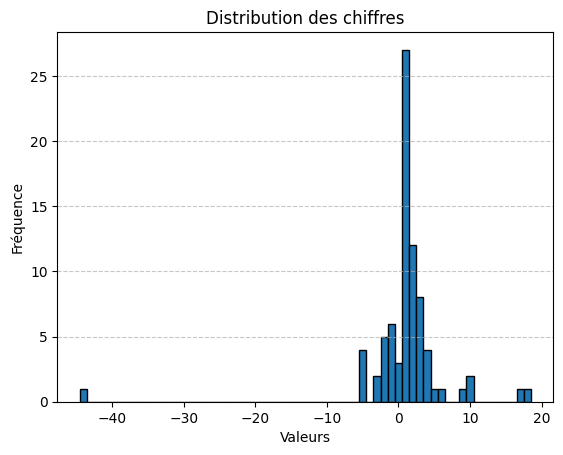

In [70]:
import matplotlib.pyplot as plt

# Exemple de liste d'entiers
liste_de_chiffres = score_reel

# Création de l'histogramme
plt.hist(liste_de_chiffres, bins=range(min(liste_de_chiffres), max(liste_de_chiffres) + 2), align='left', edgecolor='black')

# Ajout des titres et labels
plt.title("Distribution des chiffres")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")

# Affichage
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
